In [1]:
from tokenizers import Tokenizer
from tokenizers.processors import TemplateProcessing
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
from torch.nn.utils.rnn import pad_sequence
import torch.nn.functional as F
import pandas as pd
import numpy as np
import copy
from tqdm import tqdm

In [2]:
train_df = pd.read_csv('/kaggle/input/datasets/thedevastator/tinystories-narrative-classification/train.csv').dropna()
test_df = pd.read_csv('/kaggle/input/datasets/thedevastator/tinystories-narrative-classification/validation.csv')

In [3]:
tokenizer = Tokenizer.from_file('/kaggle/input/notebooks/naneet1/blockformer-tokenizer/BlockFormer.json')

In [4]:
bos_id = tokenizer.token_to_id("<bos>")
eos_id = tokenizer.token_to_id("<eos>")

tokenizer.post_processor = TemplateProcessing(
    single="<bos> $A <eos>",
    special_tokens=[
        ("<bos>", bos_id),
        ("<eos>", eos_id),
    ],
)

In [5]:
class TinyStories(Dataset):
    def __init__(self, df, tokenizer):
        self.df = df
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        text = self.df['text'].iloc[idx]
        ids = self.tokenizer.encode(text).ids
        tensor_ids = torch.tensor(ids)
        return tensor_ids

In [6]:
def collate_fn(batch):

    input_ids = pad_sequence(batch, batch_first=True, padding_value=0)

    b, s = input_ids.shape

    attention_mask = (input_ids == 0)

    causal_mask = torch.triu(
        torch.ones(s, s), diagonal=1
    ).bool()

    return input_ids, attention_mask, causal_mask

In [7]:
train_dataset = TinyStories(df=train_df, tokenizer=tokenizer)
test_dataset = TinyStories(df=test_df, tokenizer=tokenizer)

In [8]:
train_dataloader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=4,
    prefetch_factor=4
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=4,
    prefetch_factor=4
)

In [9]:
input_ids, attention_mask, causal_mask = next(iter(train_dataloader))

In [10]:
input_ids.shape, attention_mask.shape, causal_mask.shape

(torch.Size([16, 362]), torch.Size([16, 362]), torch.Size([362, 362]))

In [11]:
class RoPE(nn.Module):
    def __init__(
        self,
        nhead,
        d_model,
        max_seq_len
    ):
        super().__init__()
        head_dim = d_model // nhead
        assert head_dim % 2 == 0
        d = head_dim

        k = torch.arange(head_dim // 2, dtype=torch.float32)
        inv_freq = 10000 ** (-2 * k / head_dim)

        positions = torch.arange(max_seq_len, dtype=torch.float32)
        angles = torch.outer(positions, inv_freq)

        cos_cache = torch.cos(angles).repeat_interleave(repeats=2, dim=-1)[None, None, :, :]
        sin_cache = torch.sin(angles).repeat_interleave(repeats=2, dim=-1)[None, None, :, :]

        self.register_buffer('cos_cache', cos_cache)
        self.register_buffer('sin_cache', sin_cache)


    def rotate(self, x):
        x_even = x[..., 0::2]
        x_odd = x[..., 1::2]

        rotate_even = -x_odd
        rotate_odd = x_even

        rotate = torch.stack([rotate_even, rotate_odd], dim=-1).reshape(*x.shape)

        return rotate

    def forward(self, x, offset=None):
        B, H, S, D = x.shape

        if offset == None:
            cos = self.cos_cache[:,:,:S,:]
            sin = self.sin_cache[:,:,:S,:]

        else:
            cos = self.cos_cache[:,:, offset:offset+S,:]
            sin = self.sin_cache[:,:, offset:offset+S,:]

        x = x * cos + self.rotate(x) * sin

        return x

In [12]:
class MHA(nn.Module):
    def __init__(
        self,
        d_model,
        nhead,
        rope,
        bias=True,
        dropout=0.0,
    ):
        super().__init__()

        assert d_model % nhead == 0
        self.nhead = nhead
        self.d_model = d_model
        self.head_dim = d_model // nhead
        assert self.head_dim % 2 == 0

        self.rope = rope

        self.w_q = nn.Linear(d_model, d_model, bias=bias)
        self.w_k = nn.Linear(d_model, d_model, bias=bias)
        self.w_v = nn.Linear(d_model, d_model, bias=bias)
        self.w_o = nn.Linear(d_model, d_model, bias=bias)

        self.dropout = nn.Dropout(dropout)

    def forward(
        self,
        input_ids,
        causal_mask=None,
        attention_mask=None,
        kv_cache=None,
        return_cache=False
    ):
        
        B, S, E = input_ids.shape
        query = self.w_q(input_ids).view(B, S, self.nhead, self.head_dim).permute(0, 2, 1, 3)
        key = self.w_k(input_ids).view(B, S, self.nhead, self.head_dim).permute(0, 2, 1, 3)
        value = self.w_v(input_ids).view(B, S, self.nhead, self.head_dim).permute(0, 2, 1, 3)

        if kv_cache != None:
            offset = kv_cache[0].shape[2]
            
            key = self.rope(key, offset=offset)
            key = torch.cat([kv_cache[0], key], dim=2)
            
            value = torch.cat([kv_cache[1], value], dim=2)
            
            kv_cache = [key, value]

            query = self.rope(query, offset=offset)

        elif return_cache:
            kv_cache = [key, value]

        else:
            query = self.rope(query)
            key = self.rope(key)

        attention = query @ key.transpose(-1, -2)
        attention = attention / (self.head_dim ** 0.5)

        if causal_mask is not None:
            causal_mask = causal_mask[None, None, :, :]
            attention = attention.masked_fill(causal_mask, float('-inf'))

        if attention_mask is not None:
            attention_mask = attention_mask[:, None, None, :]
            attention = attention.masked_fill(attention_mask, float('-inf'))

        attention = torch.softmax(attention, dim=-1)
        attention = self.dropout(attention)

        output = attention @ value
        output = output.transpose(1, 2).contiguous().view(B, S, self.d_model)
        output = self.w_o(output)
        output = self.dropout(output)

        if kv_cache == None and not return_cache:
            return output

        elif kv_cache != None or return_cache:
            return output, kv_cache

In [13]:
class TransformerDecoderLayer(nn.Module):
    def __init__(
        self,
        rope,
        d_model=512,
        nhead=8,
        dim_ff=2048,
        activation=nn.GELU(),
        bias=True,
        dropout=0.0
    ):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.mha = MHA(
            d_model=d_model,
            nhead=nhead,
            rope=rope,
            bias=bias,
            dropout=dropout,
        )

        self.norm2 = nn.LayerNorm(d_model)
        self.dff = nn.Sequential(
            nn.Linear(d_model, dim_ff),
            activation,
            nn.Dropout(dropout),
            nn.Linear(dim_ff, d_model),
            nn.Dropout(dropout),
        )

    def forward(
        self,
        input_ids,
        attention_mask,
        causal_mask,
        kv_cache=None,
        return_cache=False
    ):
        
        x = input_ids
        residual = x

        if kv_cache != None or return_cache:
            x, kv_cache = self.mha(
                input_ids=self.norm1(x),
                attention_mask=attention_mask,
                causal_mask=causal_mask,
                kv_cache=kv_cache,
                return_cache=return_cache
            )
        else:
            x = self.mha(
                input_ids=self.norm1(x),
                attention_mask=attention_mask,
                causal_mask=causal_mask,
                kv_cache=kv_cache,
                return_cache=return_cache
            )
            
        x = residual + x
        
        residual = x
        x = self.dff(self.norm2(x))
        x = residual + x

        if kv_cache != None or return_cache:
            return x, kv_cache
        else:
            return x


In [121]:
class TransformerDecoder(nn.Module):
    def __init__(
        self,
        decoderlayer,
        num_layers
    ):
        super().__init__()
        self.layers = nn.ModuleList([copy.deepcopy(decoderlayer) for _ in range(num_layers)])

    def forward(
        self,
        input_ids,
        attention_mask,
        causal_mask,
        kv_cache=None,
        return_cache=False
    ):
        if return_cache and kv_cache == None:
            use_cache = True
            kv_cache = [None for _ in range(len(self.layers))]
        elif kv_cache is not None:
            use_cache = True
        else:
            use_cache = False
        x = input_ids

        for n, decoderlayer in enumerate(self.layers):
            if use_cache:
                x, kv_cache[n] = decoderlayer(
                    input_ids=x,
                    attention_mask=attention_mask,
                    causal_mask=causal_mask,
                    kv_cache=kv_cache[n],
                    return_cache=return_cache
                )

            elif return_cache:
                x, kv_cache[n] = decoderlayer(
                    input_ids=x,
                    attention_mask=attention_mask,
                    causal_mask=causal_mask,
                    kv_cache=None,
                    return_cache=return_cache
                )

            else:
                x = decoderlayer(
                    input_ids=x,
                    attention_mask=attention_mask,
                    causal_mask=causal_mask,
                    kv_cache=None,
                    return_cache=return_cache
                )

        if kv_cache != None or return_cache:
            return x, kv_cache
        else:
            return x

In [123]:
class BlockFormer(nn.Module):
    def __init__(
        self,
        d_model=512,
        nhead=8,
        num_layers=6,
        dim_ff=2048,
        dropout=0.15,
        vocab=16000,
        max_deq_len=2048
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab,
            embedding_dim=d_model,
            padding_idx=0
        )

        rope = RoPE(nhead=nhead,
                   d_model=d_model,
                   max_seq_len=max_deq_len)

        self.decoder = TransformerDecoder(
            TransformerDecoderLayer(
                rope=rope,
                d_model=512,
                nhead=8,
                dim_ff=2048,
                activation=nn.GELU(),
                bias=True,
                dropout=dropout
            ),
            num_layers=num_layers
        )

        self.ln = nn.LayerNorm(d_model)
        self.fc = nn.Linear(d_model, vocab)
        self.fc.weight = self.embedding.weight

    def forward(self, input_ids, attention_mask=None, causal_mask=None, kv_cache=None, return_cache=False):
        b, s = input_ids.shape
    
        causal_mask = torch.triu(
            torch.ones(s, s), diagonal=1
        ).bool().to('cuda')
        
        x = self.embedding(input_ids)

        if kv_cache != None or return_cache:
            x, kv_cache = self.decoder(
                input_ids=x,
                causal_mask=causal_mask,
                attention_mask=attention_mask,
                kv_cache=kv_cache,
                return_cache=return_cache
            )

            x = self.ln(x)
            logits = self.fc(x)
            return logits, kv_cache

        else:
            x = self.decoder(
                input_ids=x,
                causal_mask=causal_mask,
                attention_mask=attention_mask,
                kv_cache=kv_cache,
                return_cache=return_cache
            )

        x = self.ln(x)
        logits = self.fc(x)

        if kv_cache != None or return_cache:
            return logits, kv_cache
            
        else:
            return logits

    @torch.inference_mode()
    def generate(self, input_ids, max_new_tokens, use_cache=True):

        max_len = input_ids.size(1) + max_new_tokens
        full_mask = torch.triu(
            torch.ones(max_len, max_len), diagonal=1
        ).bool().to(input_ids.device)
        
        b, s = input_ids.shape
        preds = []
        
        for _ in range(max_new_tokens):
            if _ == 0 and use_cache:
                kv_cache = None
                return_cache=True
                preds = [input_ids]
                
            elif _ == 0 and not use_cache:
                kv_cache = None
                return_cache=False
            
            causal_mask = full_mask[:s, :s]

            if use_cache:
                logits, kv_cache = self.forward(
                    input_ids=input_ids,
                    attention_mask=None,
                    causal_mask=causal_mask,
                    kv_cache=kv_cache,
                    return_cache=return_cache
                )

            else:
                logits = self.forward(
                    input_ids=input_ids,
                    attention_mask=None,
                    causal_mask=causal_mask
                )

            temperature = 1
            logits = logits[:, -1, :] / temperature
            probs = torch.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, 1)

            if use_cache:
                preds.append(next_token)
                input_ids = next_token

            else:
                input_ids = torch.cat([input_ids, next_token], dim=1)

            s+=1
        if use_cache:
            preds = torch.cat(preds, dim=1)
            return preds

        else:
            return input_ids

In [124]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

model = BlockFormer(
    d_model=512,
    nhead=8,
    num_layers=6,
    dim_ff=2048,
    dropout=0.15,
    vocab=16000,
    max_deq_len=2048
).to('cuda')

# model = nn.DataParallel(model)
model = torch.compile(model)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.01, betas=(0.9, 0.95))

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=5,   
    eta_min=3e-5       
)

checkpoint = torch.load("/kaggle/input/models/naneet1/blockformer/pytorch/v2/1/BlockFormer_39_epochs.pth", map_location="cuda")

model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

print("Checkpoint loaded successfully.")

Checkpoint loaded successfully.


In [125]:
model = model._orig_mod

In [126]:
input_text = 'Once upon a time there was a lion'
tokens = tokenizer.encode(input_text).ids
input_ids = torch.tensor(tokens).unsqueeze(0)

In [127]:
model.eval()
output = model.generate(input_ids=input_ids.to('cuda'), max_new_tokens=256, use_cache=True)

In [128]:
print(tokenizer.decode(output[0].tolist()))

 Once upon a time there was a lion! One day the lion went to the zoo with his big lion friends. The lion was so lively that he ran around spending time erasing noises. Suddenly, one of the animals stopped and pointed discouraged.

The lion was getting smudged and mad. Then, a little rabbit came and riddle started to dream. The waddled over aparelass and told the lion, "The brave lion must have kept the voice calling!"

The lion belers thought until they had an idea. He put the bear in a bowl of water and began to pour the water over it scatter the water over the lion's birds. After a few minutes, the lion was done color and looked at Nobody use the water! Bees of the animals were surprised and ran away happily necessary.
ibbit castles were full of excitement and the lion was proud that the mouse had been able to help the animals. Even though he still had aBeep walk with the lion, he was almost able drinking. micr and the lion remainedicying the animals Remember to always permitier them

In [21]:
import time

t0 = time.time()
model.generate(input_ids.to('cuda'), max_new_tokens=512, use_cache=True)
print(f"With cache: {time.time() - t0:.2f}s")

t0 = time.time()
model.generate(input_ids.to('cuda'), max_new_tokens=512, use_cache=False)
print(f"Without cache: {time.time() - t0:.2f}s")

With cache: 1.82s
Without cache: 4.04s


In [22]:
import time
import torch

token_lengths = [64, 128, 256, 384, 512, 640, 768, 896, 1024]
results = {"with_cache": [], "without_cache": []}

for max_new_tokens in token_lengths:
    # With KV cache
    torch.cuda.synchronize()
    t0 = time.time()
    with torch.inference_mode():
        model.generate(input_ids.to('cuda'), max_new_tokens=max_new_tokens, use_cache=True)
    torch.cuda.synchronize()
    results["with_cache"].append(round(time.time() - t0, 2))

    # Without KV cache
    torch.cuda.synchronize()
    t0 = time.time()
    with torch.inference_mode():
        model.generate(input_ids.to('cuda'), max_new_tokens=max_new_tokens, use_cache=False)
    torch.cuda.synchronize()
    results["without_cache"].append(round(time.time() - t0, 2))

    print(f"tokens={max_new_tokens} | cache={results['with_cache'][-1]:.2f}s | no_cache={results['without_cache'][-1]:.2f}s | speedup={results['without_cache'][-1]/results['with_cache'][-1]:.2f}x")

tokens=64 | cache=0.23s | no_cache=0.36s | speedup=1.57x
tokens=128 | cache=0.45s | no_cache=0.73s | speedup=1.62x
tokens=256 | cache=0.90s | no_cache=1.58s | speedup=1.76x
tokens=384 | cache=1.34s | no_cache=2.59s | speedup=1.93x
tokens=512 | cache=1.76s | no_cache=4.06s | speedup=2.31x
tokens=640 | cache=2.21s | no_cache=6.00s | speedup=2.71x
tokens=768 | cache=2.71s | no_cache=8.70s | speedup=3.21x
tokens=896 | cache=3.14s | no_cache=12.32s | speedup=3.92x
tokens=1024 | cache=3.58s | no_cache=16.80s | speedup=4.69x


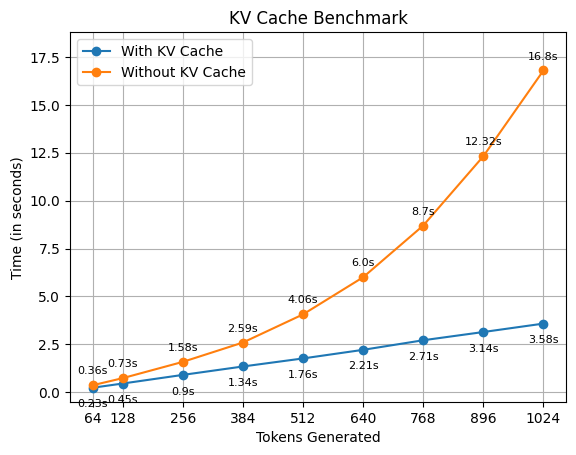

In [24]:
import matplotlib.pyplot as plt

labels = token_lengths
with_cache = results['with_cache']
without_cache = results['without_cache']

fig, ax = plt.subplots()

ax.plot(labels, with_cache, marker='o', label='With KV Cache')
ax.plot(labels, without_cache, marker='o', label='Without KV Cache')
ax.grid()
ax.set_xticks(labels)
ax.set_ylabel('Time (in seconds)')
ax.set_xlabel('Tokens Generated')
ax.set_title('KV Cache Benchmark')

for x, y in zip(labels, with_cache):
    ax.annotate(f"{y}s", (x, y), textcoords="offset points", xytext=(0, -14), ha="center", fontsize=8)
for x, y in zip(labels, without_cache):
    ax.annotate(f"{y}s", (x, y), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)

ax.set_ylim(bottom=-0.5, top=max(without_cache) + 2)
ax.legend()
plt.show()

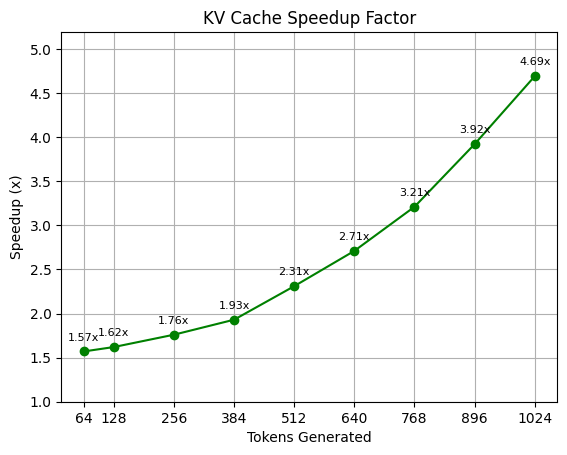

In [25]:
speedups = [round(b/a, 2) for a, b in zip(with_cache, without_cache)]

plt.plot(labels, speedups, marker='o', color='green')
plt.grid()
plt.xticks(labels)
plt.ylabel('Speedup (x)')
plt.xlabel('Tokens Generated')
plt.title('KV Cache Speedup Factor')

for x, y in zip(labels, speedups):
    plt.annotate(f"{y}x", (x, y), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)

plt.ylim(bottom=1, top=max(speedups) + 0.5)
plt.show()

In [26]:
sum(p.numel() for p in model.parameters())

27123328

In [1]:
epochs = list(range(1, 41))

train_loss = [
    4.6663, 3.9783, 3.7579, 3.6644, 3.6215, 3.6006, 3.5734, 3.5244, 3.4718, 3.4222,
    3.3753, 3.3298, 3.2875, 3.2483, 3.2103, 3.1731, 3.1387, 3.1163, 3.0940, 3.0848,
    3.0703, 3.0475, 3.0279, 3.0112, 3.0008, 2.9911, 2.9817, 2.9732, 2.9668, 2.9561,
    2.9527, 2.9495, 2.9420, 2.9383, 2.9334, None, None, None, 2.9218, 2.9175
]

test_loss = [
    4.1818, 3.7541, 3.5826, 3.5007, 3.4652, 3.4473, 3.4184, 3.3625, 3.3141, 3.2669,
    3.2217, 3.1789, 3.1413, 3.1034, 3.0682, 3.0379, 3.0048, 2.9844, 2.9664, 2.9543,
    2.9345, 2.9203, 2.9035, 2.8910, 2.8808, 2.8742, 2.8697, 2.8566, 2.8485, 2.8418,
    2.8375, 2.8329, 2.8291, 2.8283, 2.8187, None, None, None, 2.8074, 2.8085
]

perplexity = [
    65.48, 42.69, 35.97, 33.14, 31.98, 31.42, 30.52, 28.86, 27.50, 26.23,
    25.07, 24.02, 23.13, 22.27, 21.50, 20.86, 20.18, 19.77, 19.42, 19.19,
    18.81, 18.55, 18.24, 18.01, 17.83, 17.71, 17.63, 17.40, 17.26, 17.15,
    17.07, 16.99, 16.93, 16.92, 16.76, None, None, None, 16.57, 16.59
]

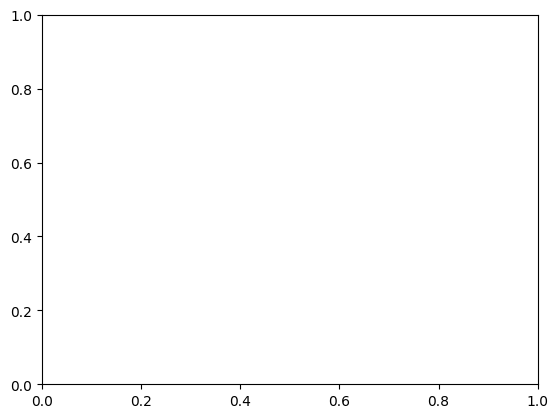

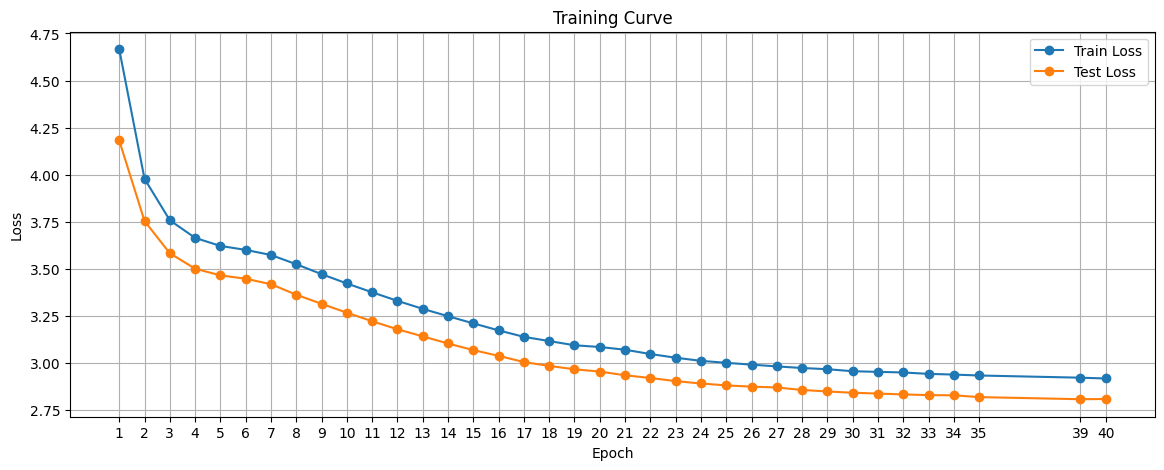

In [4]:
import matplotlib.pyplot as plt

def filter_none(xs, ys):
    return zip(*[(x, y) for x, y in zip(xs, ys) if y is not None])

fig, ax = plt.subplots()
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(*filter_none(epochs, train_loss), marker='o', label='Train Loss')
ax.plot(*filter_none(epochs, test_loss), marker='o', label='Test Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training Curve')
ax.set_xticks([e for e, v in zip(epochs, train_loss) if v is not None])
ax.grid()
ax.legend()
plt.show()

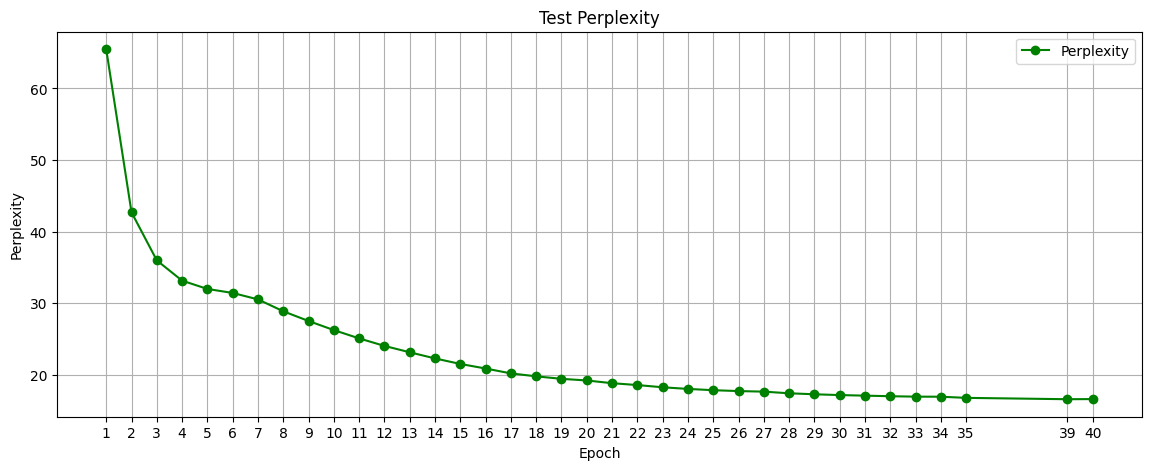

In [5]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(*filter_none(epochs, perplexity), marker='o', color='green', label='Perplexity')
ax.set_xlabel('Epoch')
ax.set_ylabel('Perplexity')
ax.set_title('Test Perplexity')
ax.set_xticks([e for e, v in zip(epochs, perplexity) if v is not None])
ax.grid()
ax.legend()
plt.show()